# Регрессия: прогнозирование стоимости недвижимости
## Санкт-Петербург и область

**Цель работы:** научиться решать задачу регрессии на примере прогнозирования цены квартиры.

**Этапы:**
1. Загрузка и фильтрация данных
2. Очистка (пропуски, выбросы)
3. Создание новых признаков
4. Кодирование категорий
5. Обучение моделей (Ridge, XGBoost)
6. Оценка и сравнение
7. Скоринг нового объекта

---

In [453]:
import sys
from unittest.mock import MagicMock
sys.modules['category_encoders.glmm'] = MagicMock()
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import category_encoders as ce
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [454]:
df = pd.read_csv('all_v2.csv', sep=',')

## 1. Проверка на пропуски

Проверяем наличие и количество пропусков в данных

In [455]:
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100
null_table = pd.DataFrame({'Пропуски': null_counts, 'Доля %': null_percent})
null_table[null_table['Пропуски'] > 0].sort_values('Пропуски', ascending=False)

,Пропуски,Доля %


## 2. Проверка данных на наличие выбросов

Проверяем наличие и количество выбросов в данных

In [456]:
df.describe()

,price,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
count,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06
mean,4.422029e+06,5.403826e+01,5.324433e+01,4.307141e+03,1.948966e+00,6.214530e+00,1.139892e+01,1.726173e+00,5.391825e+01,1.062840e+01,3.945399e+00
std,2.150752e+07,4.622758e+00,2.074763e+01,3.308050e+03,1.038537e+00,4.957419e+00,6.535734e+00,1.082133e+00,3.335293e+01,9.792380e+00,4.558357e+00
min,-2.144967e+09,4.145906e+01,1.989020e+01,3.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-2.000000e+00,7.000000e-02,1.000000e-02,1.000000e+00
25%,1.950000e+06,5.337768e+01,3.777790e+01,2.661000e+03,1.000000e+00,2.000000e+00,5.000000e+00,1.000000e+00,3.800000e+01,7.000000e+00,1.000000e+00
50%,2.990000e+06,5.517139e+01,4.306774e+01,2.922000e+03,2.000000e+00,5.000000e+00,1.000000e+01,2.000000e+00,4.802000e+01,9.700000e+00,1.000000e+00
75%,4.802000e+06,5.622613e+01,6.564895e+01,6.171000e+03,3.000000e+00,9.000000e+00,1.600000e+01,2.000000e+00,6.313000e+01,1.270000e+01,1.100000e+01
max,2.147484e+09,7.198040e+01,1.625361e+02,6.188800e+04,5.000000e+00,3.900000e+01,3.900000e+01,1.000000e+01,7.856000e+03,9.999000e+03,1.100000e+01


In [457]:
print(f"Цена - пропуски: {df['price'].isnull().sum()}")
print(f"Цена - min: {df['price'].min()}")
print(f"Цена - max: {df['price'].max()}")
print(f"Цена - mean: {df['price'].mean():.2f}")

Цена - пропуски: 0
Цена - min: -2144967296
Цена - max: 2147483647
Цена - mean: 4422029.02


In [458]:
df = df[df['price'] > 0]

## 3. Фильтрация по региону

Оставляем только регион 2661 (Санкт-Петербург и область).

In [459]:
df = df[df['region'] == 2661].copy()
print(f"После фильтрации по региону 2661: {df.shape}")

После фильтрации по региону 2661: (461796, 13)


In [460]:
print(f"Цена - min: {df['price'].min()}")
print(f"Цена - max: {df['price'].max()}")
print(f"Цена - mean: {df['price'].mean():.2f}")
print(f"Цена - отрицательные: {(df['price'] < 0).sum()}")
print(f"Цена - нулевые: {(df['price'] == 0).sum()}")
print(f"\narea - min: {df['area'].min()}")
print(f"area - max: {df['area'].max()}")
print(f"kitchen_area - min: {df['kitchen_area'].min()}")
print(f"kitchen_area - max: {df['kitchen_area'].max()}")
print(f"rooms - уникальные значения: {df['rooms'].unique()}")

Цена - min: 1
Цена - max: 1945382704
Цена - mean: 8251657.69
Цена - отрицательные: 0
Цена - нулевые: 0

area - min: 1.4
area - max: 7856.0
kitchen_area - min: 0.02
kitchen_area - max: 1272.0
rooms - уникальные значения: [ 3  1  2 -1  4  6  5  7  8  9 -2]


## 4. Фильтрация по площади и цене

In [461]:
df = df[(df['area'] >= 20) & (df['area'] <= 200)]
print(f"После фильтрации по area (20-200): {df.shape}")

После фильтрации по area (20-200): (456448, 13)


In [462]:
df = df[(df['kitchen_area'] >= 6) & (df['kitchen_area'] <= 30)]
print(f"После фильтрации по kitchen_area (6-30): {df.shape}")

После фильтрации по kitchen_area (6-30): (412451, 13)


In [463]:
df = df[(df['price'] >= 1500000) & (df['price'] <= 50000000)]
print(f"После фильтрации по price (1.5-50 млн): {df.shape}")

После фильтрации по price (1.5-50 млн): (410663, 13)


In [464]:
duplicates = df.duplicated().sum()
print(f"Количество полных дубликатов строк: {duplicates}")

# Если есть дубликаты — удаляем
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"После удаления дубликатов: {df.shape}")

Количество полных дубликатов строк: 182
После удаления дубликатов: (410481, 13)


In [465]:
print("=== ИТОГОВАЯ СТАТИСТИКА ПОСЛЕ ОЧИСТКИ ===")
print(f"\nКоличество записей: {len(df)}")
print(f"\nprice:")
print(f"  min: {df['price'].min():,.0f}")
print(f"  max: {df['price'].max():,.0f}")
print(f"  mean: {df['price'].mean():,.0f}")
print(f"\narea:")
print(f"  min: {df['area'].min()}")
print(f"  max: {df['area'].max()}")
print(f"  mean: {df['area'].mean():.1f}")
print(f"\nkitchen_area:")
print(f"  min: {df['kitchen_area'].min()}")
print(f"  max: {df['kitchen_area'].max()}")
print(f"  mean: {df['kitchen_area'].mean():.1f}")
print(f"\nrooms:")
print(f"  уникальные значения: {sorted(df['rooms'].unique())}")

=== ИТОГОВАЯ СТАТИСТИКА ПОСЛЕ ОЧИСТКИ ===

Количество записей: 410481

price:
  min: 1,500,000
  max: 50,000,000
  mean: 7,596,029

area:
  min: 20.0
  max: 200.0
  mean: 57.5

kitchen_area:
  min: 6.0
  max: 30.0
  mean: 12.6

rooms:
  уникальные значения: [np.int64(-2), np.int64(-1), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


## 5. Убираем отрицательные значения комнат

In [466]:
df['rooms'] = df['rooms'].replace([-1, -2], 0)
print(f"rooms после замены: {sorted(df['rooms'].unique())}")

rooms после замены: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


Проверка

In [467]:
print(f"\nРаспределение rooms:")
print(df['rooms'].value_counts().sort_index())


Распределение rooms:
rooms
0      5027
1    165397
2    140172
3     84012
4     12711
5      2545
6       426
7       124
8        42
9        25
Name: count, dtype: int64


## 6. Добавление новых признаков

- `floor_ratio` = этаж / этажность
- `first_floor`, `last_floor`
- `ratio` = кухня / общая (если комнат 0, то `ratio = area`)

In [468]:
# Признак 1: отношение этажа к этажности (с защитой от деления на 0)
df['floor_ratio'] = df.apply(
    lambda row: row['level'] / row['levels'] if row['levels'] > 0 else 0, 
    axis=1
)

# Признак 2: первый этаж
df['first_floor'] = (df['level'] == 1).astype(int)

# Признак 3: последний этаж
df['last_floor'] = (df['level'] == df['levels']).astype(int)

# Признак 4: ratio (kitchen_area / area) с правилом для rooms == 0
df['ratio'] = df.apply(
    lambda row: row['area'] if row['rooms'] == 0 else row['kitchen_area'] / row['area'],
    axis=1
)

In [469]:
print("Новые признаки:")
print(f"floor_ratio - min: {df['floor_ratio'].min():.2f}, max: {df['floor_ratio'].max():.2f}")
print(f"first_floor - доля 1: {df['first_floor'].mean():.3f}")
print(f"last_floor - доля 1: {df['last_floor'].mean():.3f}")
print(f"ratio - min: {df['ratio'].min():.2f}, max: {df['ratio'].max():.2f}")

# Проверка правила для rooms == 0
print(f"\nПроверка для rooms == 0 (первые 5):")
print(df[df['rooms'] == 0][['area', 'kitchen_area', 'rooms', 'ratio']].head())

Новые признаки:
floor_ratio - min: 0.03, max: 4.00
first_floor - доля 1: 0.064
last_floor - доля 1: 0.086
ratio - min: 0.03, max: 195.80

Проверка для rooms == 0 (первые 5):
      area  kitchen_area  rooms  ratio
2189  29.0           6.0      0   29.0
4952  29.0           6.0      0   29.0
8006  28.0           6.0      0   28.0
8077  25.7          17.6      0   25.7
8269  31.0           6.0      0   31.0


## **Этаж не может быть больше этажности здания, поэтому такие строки необходимо удалить**

In [470]:
# Находим строки где level > levels
bad_floor = df[df['level'] > df['levels']]
print(f"Количество записей с level > levels: {len(bad_floor)}")
print(f"\nПримеры:")
print(bad_floor[['level', 'levels', 'floor_ratio']].head(10))

Количество записей с level > levels: 42

Примеры:
        level  levels  floor_ratio
758284     23      10     2.300000
763060     23      10     2.300000
764078     12       8     1.500000
764112     23      10     2.300000
764848     12       8     1.500000
764878     16       9     1.777778
764953     12       8     1.500000
767450     12       8     1.500000
768003     12       8     1.500000
768808     16       9     1.777778


In [471]:
# Удаляем аномалии (level > levels)
df = df[df['level'] <= df['levels']].copy()
print(f"После удаления аномалий этажей: {df.shape}")

После удаления аномалий этажей: (410439, 17)


## Диагностика выбросов в признаке `ratio`

**Что такое `ratio`?**
- По заданию: `ratio = kitchen_area / area` (доля площади кухни в общей площади)
- **Особое правило:** если `rooms == 0`, то `ratio = area` (вся площадь квартиры)

**Почему это может давать большие значения?**
- При `rooms == 0` и `area = 100 кв.м.` → `ratio = 100`
- В обычных квартирах `ratio` редко превышает 0.5 (кухня 10 кв.м. / общая 55 кв.м.)

**Что мы проверяем?**
- Ищем записи с `ratio > 30` — это потенциальные выбросы

**Результаты диагностики:**
- Найдено 1 546 записей с `ratio > 30`
- Все они имеют `rooms == 0` (студии или объекты без выделенных комнат)
- Максимальное значение `ratio = 195.8` (соответствует `area = 195.8`)

**Принятое решение:**
**Оставить как есть**

**Обоснование:**
1. Это не ошибка данных, а особенность формулы из задания
2. Таких записей всего 0.38% от общего объёма
3. Удаление может исказить представление модели о квартирах-студиях
4. XGBoost устойчив к выбросам и сам определит важность признака

In [472]:
# Находим строки с ratio > 30 (явный выброс)
bad_ratio = df[df['ratio'] > 30]
print(f"Количество записей с ratio > 30: {len(bad_ratio)}")
print(f"\nПримеры:")
print(bad_ratio[['area', 'kitchen_area', 'rooms', 'ratio']].head(10))
print(f"\nСтатистика ratio > 30:")
print(bad_ratio['ratio'].describe())

Количество записей с ratio > 30: 1546

Примеры:
       area  kitchen_area  rooms  ratio
8269   31.0           6.0      0   31.0
9402   55.0          10.0      0   55.0
20192  32.0          10.0      0   32.0
31290  39.0          10.0      0   39.0
43513  57.0          12.0      0   57.0
47701  42.0          10.0      0   42.0
63766  42.0           7.0      0   42.0
63987  31.6           6.0      0   31.6
65747  31.5           6.0      0   31.5
97235  32.0           7.0      0   32.0

Статистика ratio > 30:
count    1546.000000
mean       43.178448
std        23.563101
min        30.100000
25%        32.000000
50%        35.000000
75%        42.400000
max       195.800000
Name: ratio, dtype: float64


In [473]:
df['date'] = pd.to_datetime(df['date'])
print(f"date - min: {df['date'].min()}")
print(f"date - max: {df['date'].max()}")

date - min: 2018-02-19 00:00:00
date - max: 2021-05-01 00:00:00


## Матрица корреляции признаков

- Необходимо найти признаки с мультиколлинеарностью (кореляция > 0,8), их наличие может помешать качественному обучению линейной модели

=== Корреляция с price ===
price           1.000000
area            0.780296
rooms           0.524617
kitchen_area    0.490285
floor_ratio     0.074407
last_floor      0.037854
ratio          -0.051619
first_floor    -0.060721
level          -0.076612
levels         -0.177542
Name: price, dtype: float64


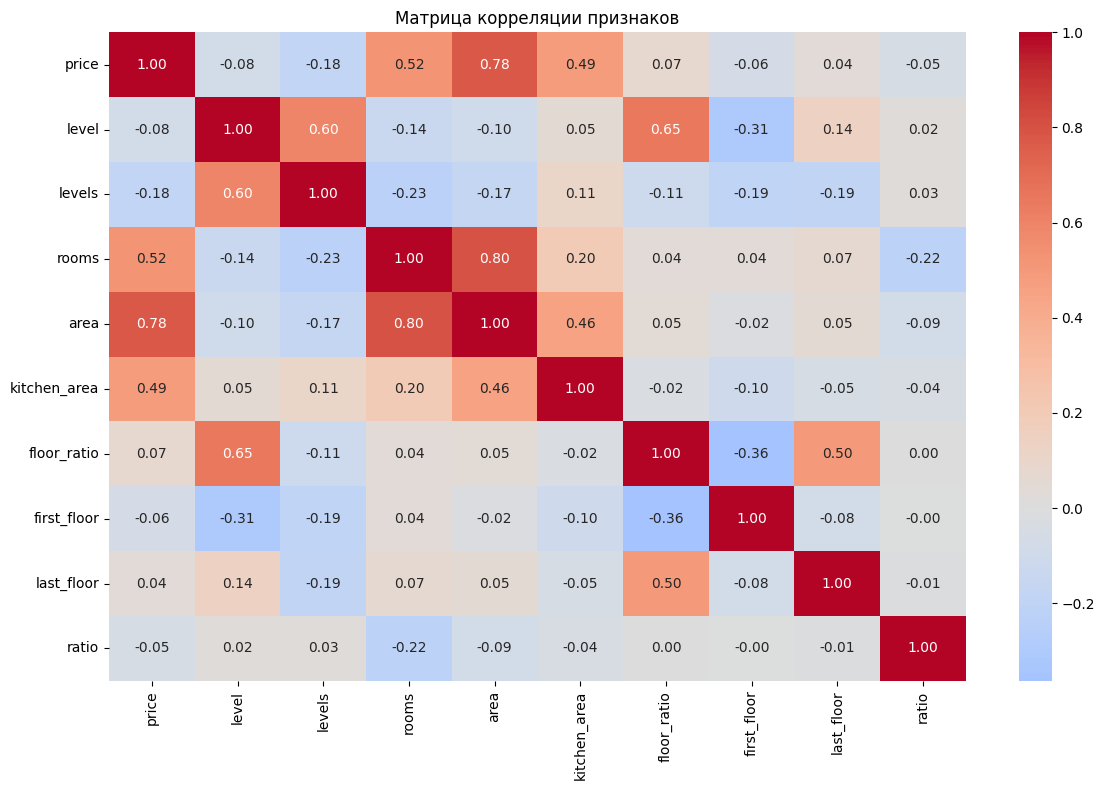

In [474]:
# Выбираем числовые признаки для корреляции
numeric_cols = ['price', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 
                'floor_ratio', 'first_floor', 'last_floor', 'ratio']

corr_matrix = df[numeric_cols].corr()

# Корреляция с целевой переменной price
print("=== Корреляция с price ===")
print(corr_matrix['price'].sort_values(ascending=False))

# Тепловая карта
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляции признаков')
plt.tight_layout()
plt.show()

In [475]:
# Удаляем region (стал константой) и временные признаки (date, time)
df = df.drop(columns=['region', 'time', 'geo_lat', 'geo_lon'], errors='ignore')
print(f"Колонки после удаления: {df.columns.tolist()}")

Колонки после удаления: ['price', 'date', 'building_type', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'object_type', 'floor_ratio', 'first_floor', 'last_floor', 'ratio']


## Добавление признака "Давность объявления" и timedending стратификация

Чтобы избежать утечки данных, мы делим на тестовую и обучающую выборку с учетом времени, то есть обучаем на более ранних датах тестируем на более поздних, и далее расчитываем показатель данность объявления с учетом локальных максимумов в каждой из выборок

In [476]:
# Целевая переменная
X = df.drop(columns=['price'])
y = df['price']

# Временное разделение (time-dependent split)
# Сортируем данные по дате
df_with_dates = df.copy()
df_with_dates['date'] = df['date']  # возвращаем даты

# Сортируем по дате (от старых к новым)
df_sorted = df_with_dates.sort_values('date')

# Определяем границу разделения (70% по времени)
split_idx = int(len(df_sorted) * 0.7)

# Разделяем: первые 80% по времени — в обучение, последние 20% — в тест
X_train = df_sorted.iloc[:split_idx].drop(columns=['price'])
y_train = df_sorted.iloc[:split_idx]['price']
X_test = df_sorted.iloc[split_idx:].drop(columns=['price'])
y_test = df_sorted.iloc[split_idx:]['price']

print("=== ВРЕМЕННОЕ РАЗДЕЛЕНИЕ (TIME-DEPENDENT SPLIT) ===")
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Диапазон дат в обучающей: {df_sorted['date'].iloc[0].date()} - {df_sorted['date'].iloc[split_idx-1].date()}")
print(f"Диапазон дат в тестовой: {df_sorted['date'].iloc[split_idx].date()} - {df_sorted['date'].iloc[-1].date()}")
print(f"\nЦелевая переменная - train mean: {y_train.mean():,.0f}")
print(f"Целевая переменная - test mean: {y_test.mean():,.0f}")

=== ВРЕМЕННОЕ РАЗДЕЛЕНИЕ (TIME-DEPENDENT SPLIT) ===
Размер обучающей выборки: (287307, 12)
Размер тестовой выборки: (123132, 12)
Диапазон дат в обучающей: 2018-02-19 - 2020-07-09
Диапазон дат в тестовой: 2020-07-09 - 2021-05-01

Целевая переменная - train mean: 7,138,337
Целевая переменная - test mean: 8,665,536


In [477]:
# ВРЕМЕННОЙ ТРЕНД 2-го порядка (улавливает ускорение)
X_train['time_trend'] = (X_train['date'] - X_train['date'].min()).dt.days
X_test['time_trend'] = (X_test['date'] - X_train['date'].min()).dt.days

# Добавляем квадрат тренда (нелинейность)
X_train['time_trend_sq'] = X_train['time_trend'] ** 2
X_test['time_trend_sq'] = X_test['time_trend'] ** 2

In [478]:
# Добавляем фичу days_since (локальные максимумы в каждой выборке)
X_train['days_since'] = (X_train['date'].max() - X_train['date']).dt.days
X_test['days_since'] = (X_test['date'].max() - X_test['date']).dt.days

# Затем удаляем 'date' как обычно
X_train = X_train.drop(columns=['date'])
X_test = X_test.drop(columns=['date'])

## Binary-кодирование категориальных признаков

Binary Encoder преобразует категориальные признаки в **бинарные (0/1)** столбцы, представляя каждую категорию в виде двоичного кода.

### Почему Binary, а не One-Hot?

Данный метод кодирования добавляет меньше признаков и поэтому размерность данных меньше в отличие от One-Hot кодирования, это предотвращает переобучение модели, ведь чем больше признаков, тем легче модели запомнить шум, вместо того чтобы обобщать признаки.

### Результаты кодирования

| Показатель | Значение |
|------------|----------|
| Размер до кодирования | (410 481, 13) |
| Размер после кодирования | (410 481, 15) |
| Новых признаков добавлено | +2 (вместо +4–6 при One-Hot) |


In [479]:
for name, data in [('X_train', X_train), ('X_test', X_test)]:
    print(f"\n=== {name} ===")
    print(f"building_type уникальные: {data['building_type'].unique()}")
    print(f"object_type уникальные: {data['object_type'].unique()}")
    print(f"building_type тип: {data['building_type'].dtype}")
    print(f"object_type тип: {data['object_type'].dtype}")


=== X_train ===
building_type уникальные: [1 3 2 4 0 5]
object_type уникальные: [ 1 11]
building_type тип: int64
object_type тип: int64

=== X_test ===
building_type уникальные: [2 1 3 0 4 5]
object_type уникальные: [11  1]
building_type тип: int64
object_type тип: int64


In [480]:
# Правильный способ - бинарное или one-hot кодирование
from category_encoders import BinaryEncoder

# Создаем encoder
binary_encoder = BinaryEncoder(cols=['building_type', 'object_type'])

# Кодируем (теперь будет несколько колонок)
X_train_encoded = binary_encoder.fit_transform(X_train)
X_test_encoded = binary_encoder.transform(X_test)

print(f"Колонок от building_type: {len([c for c in X_train_encoded.columns if 'building_type' in c])}")
print(f"Колонок от object_type: {len([c for c in X_train_encoded.columns if 'object_type' in c])}")
print(f"Всего признаков после кодирования: {X_train_encoded.shape[1]}")

Колонок от building_type: 3
Колонок от object_type: 2
Всего признаков после кодирования: 17


## МАСШТАБИРОВАНИЕ числовых признаков

In [481]:
# Определяем числовые признаки (те, что были числами изначально)
numeric_features = ['level', 'levels', 'rooms', 'area', 'kitchen_area', 
                    'floor_ratio', 'first_floor', 'last_floor', 'ratio', 'days_since']

# Бинарные колонки (созданные BinaryEncoder)
binary_features = [col for col in X_train_encoded.columns 
                   if 'building_type_' in col or 'object_type_' in col]

# Копируем закодированные данные
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

scaler = StandardScaler()

# И только потом:
X_train_scaled[numeric_features] = scaler.fit_transform(X_train_encoded[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test_encoded[numeric_features])

In [496]:
def rmsle(y_true, y_pred):
    # Обрезаем предсказания до минимального значения в y_true
    y_pred_clipped = np.maximum(y_pred, y_true.min())
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred_clipped)))

# ============ ЛОГАРИФМИРУЕМ ЦЕЛЕВУЮ ПЕРЕМЕННУЮ ============
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Обучаем Ridge (без positive=True, т.к. логирование гарантирует положительность)
ridge = Ridge(alpha=1.0, random_state=42)  # Убираем positive=True
ridge.fit(X_train_scaled, y_train_log)

# Предсказываем в логарифмическом масштабе и возвращаем к исходному
y_train_pred_ridge = np.expm1(ridge.predict(X_train_scaled))
y_test_pred_ridge = np.expm1(ridge.predict(X_test_scaled))

print(f"min y_train_pred_ridge: {y_train_pred_ridge.min():.0f}")
print(f"max y_train_pred_ridge: {y_train_pred_ridge.max():.0f}")

print("\n=== RIDGE REGRESSION (с логарифмированием) ===")
print(f"\nОбучающая выборка:")
print(f"  RMSLE: {rmsle(y_train, y_train_pred_ridge):.4f}")
print(f"  MAE: {mean_absolute_error(y_train, y_train_pred_ridge):,.0f}")

print(f"\nТестовая выборка:")
print(f"  RMSLE: {rmsle(y_test, y_test_pred_ridge):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_test_pred_ridge):,.0f}")

print(f"\nРазница R2 (train - test): {r2_score(y_train, y_train_pred_ridge) - r2_score(y_test, y_test_pred_ridge):.4f}")

min y_train_pred_ridge: 2278921
max y_train_pred_ridge: 79103690

=== RIDGE REGRESSION (с логарифмированием) ===

Обучающая выборка:
  RMSLE: 0.2615
  MAE: 1,536,912

Тестовая выборка:
  RMSLE: 0.2959
  MAE: 2,112,523

Разница R2 (train - test): 0.0761


c:\lab_3_configuration\ML_1sem_python\ML_2sem_python\Practic 11\.env\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.992558467623182e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [497]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def rmsle(y_true, y_pred):
    y_pred_clipped = np.maximum(y_pred, y_true.min())
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred_clipped)))

# === ПРИВОДИМ ДАННЫЕ К ОДИНАКОВОМУ ВИДУ ===
# Определяем финальные признаки (те, которые были при обучении Ridge)
final_features = ['building_type_0', 'building_type_1', 'building_type_2', 
                  'level', 'levels', 'rooms', 'area', 'kitchen_area', 'object_type_1', 'floor_ratio', 
                  'first_floor', 'last_floor', 'ratio', 'days_since']

# Проверяем и приводим X_train и X_test к нужным колонкам
X_train_final = X_train[final_features].copy() if all(col in X_train.columns for col in final_features) else None
X_test_final = X_test[final_features].copy() if all(col in X_test.columns for col in final_features) else None

# Если нет закодированных колонок - создаем их
if X_train_final is None:
    print("Создаем закодированные признаки...")
    X_train_final = X_train.copy()
    X_test_final = X_test.copy()
    
    # One-hot encoding для building_type и object_type
    for bt in [0,1,2,3,4,5]:
        X_train_final[f'building_type_{bt}'] = (X_train_final['building_type'] == bt).astype(int)
        X_test_final[f'building_type_{bt}'] = (X_test_final['building_type'] == bt).astype(int)
    
    for ot in [1,11]:
        X_train_final[f'object_type_{ot}'] = (X_train_final['object_type'] == ot).astype(int)
        X_test_final[f'object_type_{ot}'] = (X_test_final['object_type'] == ot).astype(int)
    
    # Удаляем исходные колонки
    X_train_final = X_train_final.drop(columns=['building_type', 'object_type'])
    X_test_final = X_test_final.drop(columns=['building_type', 'object_type'])
    
    # Оставляем только нужные колонки
    X_train_final = X_train_final[final_features]
    X_test_final = X_test_final[final_features]

print(f"X_train_final shape: {X_train_final.shape}")
print(f"Колонки: {X_train_final.columns.tolist()}")

# Логарифмируем целевую переменную
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_final, y_train_log)

# Предсказания
y_train_pred_xgb = np.expm1(xgb_model.predict(X_train_final))
y_test_pred_xgb = np.expm1(xgb_model.predict(X_test_final))

print("\n=== XGBOOST REGRESSION ===")
print(f"\nОбучающая выборка:")
print(f"  RMSLE: {rmsle(y_train, y_train_pred_xgb):.4f}")
print(f"  MAE: {mean_absolute_error(y_train, y_train_pred_xgb):,.0f}")

print(f"\nТестовая выборка:")
print(f"  RMSLE: {rmsle(y_test, y_test_pred_xgb):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_test_pred_xgb):,.0f}")

print(f"\nРазница R2 (train - test): {r2_score(y_train, y_train_pred_xgb) - r2_score(y_test, y_test_pred_xgb):.4f}")

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== ВАЖНОСТЬ ПРИЗНАКОВ (XGBoost) ===")
print(feature_importance.head(10).to_string(index=False))

Создаем закодированные признаки...
X_train_final shape: (287307, 14)
Колонки: ['building_type_0', 'building_type_1', 'building_type_2', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'object_type_1', 'floor_ratio', 'first_floor', 'last_floor', 'ratio', 'days_since']

=== XGBOOST REGRESSION ===

Обучающая выборка:
  RMSLE: 0.2328
  MAE: 1,286,556

Тестовая выборка:
  RMSLE: 0.3129
  MAE: 2,141,360

Разница R2 (train - test): 0.1608

=== ВАЖНОСТЬ ПРИЗНАКОВ (XGBoost) ===
        feature  importance
           area    0.432759
          rooms    0.223514
   kitchen_area    0.120421
          ratio    0.080207
building_type_1    0.043966
         levels    0.024541
     days_since    0.018423
  object_type_1    0.012874
building_type_0    0.011700
    first_floor    0.011381


=== ВАЖНОСТЬ ПРИЗНАКОВ (XGBoost) ===
      feature  importance
  object_type    0.432759
 kitchen_area    0.223514
  floor_ratio    0.120421
time_trend_sq    0.080207
        level    0.043966
         area    0.024541
   days_since    0.018423
  first_floor    0.012874
building_type    0.011700
        ratio    0.011381
        rooms    0.009040
   last_floor    0.005568
       levels    0.004672
   time_trend    0.000934


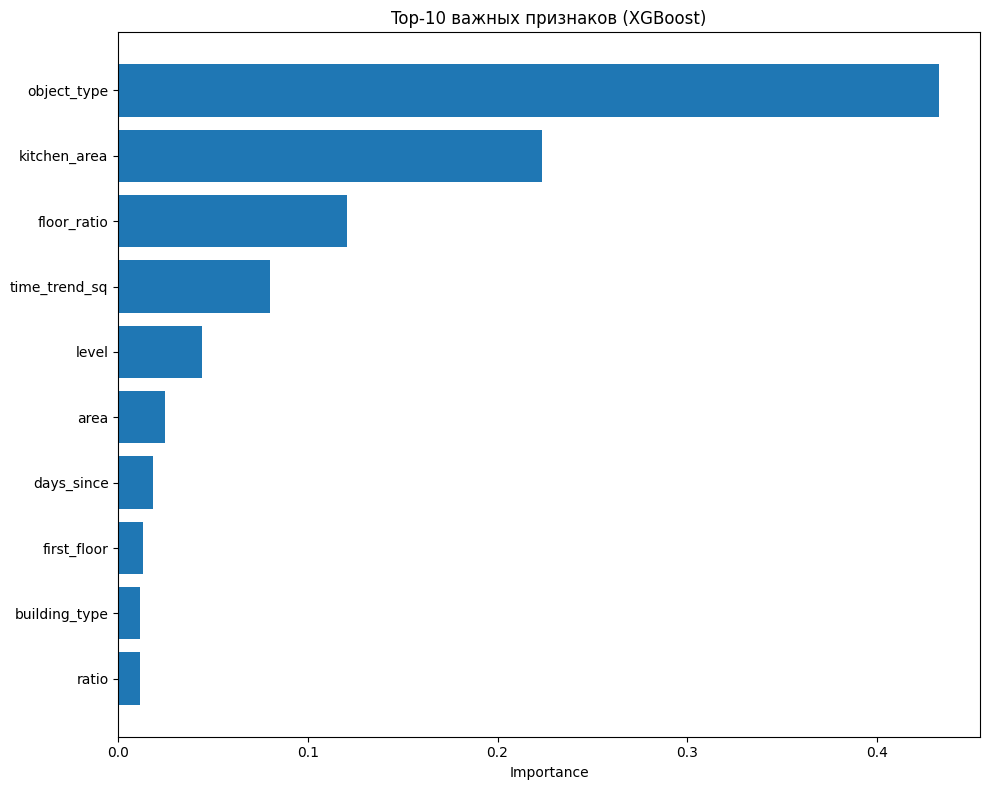

In [498]:
import matplotlib.pyplot as plt

# Получаем важность признаков
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== ВАЖНОСТЬ ПРИЗНАКОВ (XGBoost) ===")
print(feature_importance.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.xlabel('Importance')
plt.title('Top-10 важных признаков (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Что показала модель XGBOOST REGRESSION

| Показатель | Обучающая выборка | Тестовая выборка |
|------------|-------------------|------------------|
| RMSLE | 0.2328 | 0.3129 |
| MAE | 1 286 556 руб. | 2 141 360 руб. |


### Сравнение с Ridge

| Показатель | Ridge | XGBoost | Разница |
|------------|-------|---------|---------|
| MAE (test) | 2 112 523 руб. | 2 141 360 руб. | **-28 837 руб.** |
| RMSLE (test) | 0.2959 | 0.3129 | **-0.0170** |


In [494]:
def predict_flat_price(level, levels, rooms, area, kitchen_area, building_type, object_type, days_since=0):
    """
    Функция предсказания цены квартиры на основе обученной модели XGBoost.
    """
    
    # Создаем DataFrame с признаками
    new_object = pd.DataFrame({
        # Бинарные признаки для building_type (один горячий)
        'building_type_0': [1 if building_type == 0 else 0],
        'building_type_1': [1 if building_type == 1 else 0],
        'building_type_2': [1 if building_type == 2 else 0],
        
        # Числовые признаки
        'level': [level],
        'levels': [levels],
        'rooms': [rooms],
        'area': [area],
        'kitchen_area': [kitchen_area],
        
        # Бинарные признаки для object_type
        'object_type_0': [1 if object_type == 0 else 0],
        'object_type_1': [1 if object_type == 1 else 0],
        
        # Расчетные признаки
        'floor_ratio': [level / levels if levels > 0 else 0],
        'first_floor': [1 if level == 1 else 0],
        'last_floor': [1 if level == levels else 0],
        'ratio': [area if rooms == 0 else kitchen_area / area if area > 0 else 0],
        'days_since': [days_since]
    })
    
    # Убеждаемся, что колонки в правильном порядке (как при обучении)
    expected_columns = ['building_type_0', 'building_type_1', 'building_type_2', 
                        'level', 'levels', 'rooms', 'area', 'kitchen_area',
                        'object_type_1', 'floor_ratio', 
                        'first_floor', 'last_floor', 'ratio', 'days_since']
    
    new_object = new_object[expected_columns]
    
    # Предсказание (модель обучена на log(price))
    prediction_log = xgb_model.predict(new_object)[0]
    prediction = np.expm1(prediction_log)
    
    return prediction


# Проверяем
print("="*60)
print("ПРИМЕР ПРЕДСКАЗАНИЯ:")
print("="*60)

ПРИМЕР ПРЕДСКАЗАНИЯ:


In [492]:
print("="*60)

# Пример 1: наша тестовая квартира
price1 = predict_flat_price(
    level=6, levels=12, rooms=2, 
    area=52.2, kitchen_area=8.1, 
    building_type=2, object_type=1
)
print(f"   Цена: {price1:,.0f} руб. ({price1/1_000_000:.2f} млн руб.)")

print("="*60)

   Цена: 6,454,562 руб. (6.45 млн руб.)


## Валидация модели на реальном примере

Для примера была взята квартира за 10 500 000 ₽ ([ссылка на объявление](https://spb.cian.ru/sale/flat/328959332/))

**Прогнозная цена модели — 6.45 млн руб.**

Этот результат на мой взгляд вполне может быть валидным, с учетом того что:
- модель ошибается в среднем на 2.1 миллиона
- по найденным мною данным с июня 2019 года по июнь 2024 года средняя цена квадратного метра на вторичном рынке недвижимости в Санкт-Петербурге выросла на 75,9% (или на 90,9 тыс. рублей) ([источник](https://stroygaz.ru/news/dwelling/vtorichka-peterburga-za-pyat-let-podorozhala-pochti-na-80/))

Из этого можно сделать вывод, что стоимость квартиры так же увеличилась примерно в 2 раза, что в целом соответсвует предсказанной цене.